In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [62]:
res = pd.read_csv('dataTPC.csv', delimiter = ',')

In [63]:
u_rr = pd.unique(res['refresh_rate_condtion1'])
u_sc = pd.unique(res['scene'])
u_ob = pd.unique(res['observer_id'])
cols = ['sc','rr1','rr2','chrr1','chrr2', 'pct']

cols_ci = ['sc','rr1','rr2','chrr1','chrr2', 'pct', 'median', 'ci75top', 'ci75bot','ci95top','ci95bot']

In [64]:
res = res.drop(['exp_config','bandwith_condition1','bandwith_condition2'], axis=1)

In [65]:
full = pd.DataFrame(columns = cols)
for ii in range(len(u_sc)):
    for jj in range(len(u_rr)):
        for kk in range(jj+1,len(u_rr)):
            tb_tmp = res[(res['scene']==u_sc[ii]) & (res['refresh_rate_condtion1']==u_rr[jj]) & (res['refresh_rate_condtion2']==u_rr[kk])]
            tb_tmp2 = res[(res['scene']==u_sc[ii]) & (res['refresh_rate_condtion2']==u_rr[jj]) & (res['refresh_rate_condtion1']==u_rr[kk])]
            
            count = 0
            if len(tb_tmp)>0:
                for tt in range(len(tb_tmp)):
                    if ((tb_tmp['refresh_rate_condtion1'].iloc[tt]== 0) & (tb_tmp['user_selection'].iloc[tt]==1)):
                        count +=1
                    elif((tb_tmp['refresh_rate_condtion2'].iloc[tt]== 0) & (tb_tmp['user_selection'].iloc[tt]==2)):
                        count +=1
            if len(tb_tmp2)>0:
                for tt in range(len(tb_tmp2)):   
                    if ((tb_tmp2['refresh_rate_condtion1'].iloc[tt]== 0) & (tb_tmp2['user_selection'].iloc[tt]==1)):
                        count +=1
                    elif((tb_tmp2['refresh_rate_condtion2'].iloc[tt]== 0) & (tb_tmp2['user_selection'].iloc[tt]==2)):
                        count +=1
    
            tot = len(tb_tmp)+len(tb_tmp2)
            if tot>0:
                full = full.append(({'sc':u_sc[ii],
                                     'rr1':u_rr[jj],
                                     'rr2':u_rr[kk],
                                      'chrr1':count,
                                      'chrr2':(tot-count),
                                      'pct':((count+1)/(tot+2))}), ignore_index=True)
                    
                    
                full.reset_index(inplace=True, drop=True)

In [66]:
full

,sc,rr1,rr2,chrr1,chrr2,pct
0,FPS,0,60,13,1,0.8750
1,FPS,0,120,11,3,0.7500
2,FPS,0,30,14,0,0.9375
3,RTS,0,60,8,6,0.5625
4,RTS,0,120,11,3,0.7500
5,RTS,0,30,14,0,0.9375


## Bootstrapping Confidence Intervals

In [73]:
numb_bootstrap = 100

full_ci = pd.DataFrame(columns = cols_ci)
for ii in range(len(u_sc)):
    for jj in range(len(u_rr)):
        for kk in range(jj+1,len(u_rr)):
            tb_tmp = res[(res['scene']==u_sc[ii]) & (res['refresh_rate_condtion1']==u_rr[jj]) & (res['refresh_rate_condtion2']==u_rr[kk])]
            tb_tmp2 = res[(res['scene']==u_sc[ii]) & (res['refresh_rate_condtion2']==u_rr[jj]) & (res['refresh_rate_condtion1']==u_rr[kk])]
            
            
            ci_arr = np.empty(shape=[numb_bootstrap])
            tot = len(tb_tmp)+len(tb_tmp2)
            if tot>0:
                for zz in range(0,numb_bootstrap):
                    count = 0
                    if len(tb_tmp)>0:
                        arr_rnd = np.random.randint(0,len(tb_tmp),len(tb_tmp))                
                        for ff in range(len(tb_tmp)):
                            tt = arr_rnd[ff]
                            if ((tb_tmp['refresh_rate_condtion1'].iloc[tt]== 0) & (tb_tmp['user_selection'].iloc[tt]==1)):
                                count +=1
                            elif((tb_tmp['refresh_rate_condtion2'].iloc[tt]== 0) & (tb_tmp['user_selection'].iloc[tt]==2)):
                                count +=1
                    if len(tb_tmp2)>0:
                        arr_rnd = np.random.randint(0,len(tb_tmp2),len(tb_tmp2))   
                        for ff in range(len(tb_tmp2)):
                            tt = arr_rnd[ff]
                            if ((tb_tmp2['refresh_rate_condtion1'].iloc[tt]== 0) & (tb_tmp2['user_selection'].iloc[tt]==1)):
                                count +=1
                            elif((tb_tmp2['refresh_rate_condtion2'].iloc[tt]== 0) & (tb_tmp2['user_selection'].iloc[tt]==2)):
                                count +=1

                    ci_arr[zz] = ((count+1)/(tot+2))

                ci_arr=np.sort(ci_arr)
                md = ci_arr[int(numb_bootstrap/2)]
                ci75t = ci_arr[int(numb_bootstrap*0.75)]
                ci75b = ci_arr[int(numb_bootstrap*0.25)]
                ci95t = ci_arr[int(numb_bootstrap*0.95)]
                ci95b = ci_arr[int(numb_bootstrap*0.05)]
        
            if tot>0:
                full_ci = full_ci.append(({'sc':u_sc[ii],
                                     'rr1':u_rr[jj],
                                     'rr2':u_rr[kk],
                                     'chrr1':count,
                                     'chrr2':(tot-count),
                                     'pct':((count+1)/(tot+2)),
                                     'median':md,
                                     'ci75top':ci75t,
                                     'ci75bot':ci75b,
                                     'ci95top':ci95t,
                                     'ci95bot':ci95b}), ignore_index=True)
                    
                   
                full_ci.reset_index(inplace=True, drop=True)

In [70]:
full_ci

,sc,rr1,rr2,chrr1,chrr2,pct,median,ci75top,ci75bot,ci95top,ci95bot
0,FPS,0,60,14,0,0.9375,0.8750,0.9375,0.8125,0.9375,0.7500
1,FPS,0,120,10,4,0.6875,0.7500,0.8125,0.6875,0.8750,0.6250
2,FPS,0,30,14,0,0.9375,0.9375,0.9375,0.9375,0.9375,0.9375
3,RTS,0,60,7,7,0.5000,0.5625,0.6250,0.5000,0.6875,0.4375
4,RTS,0,120,12,2,0.8125,0.7500,0.8125,0.6875,0.9375,0.5625
5,RTS,0,30,14,0,0.9375,0.9375,0.9375,0.9375,0.9375,0.9375


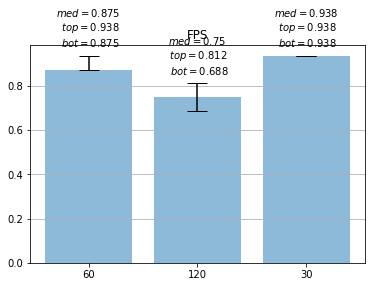

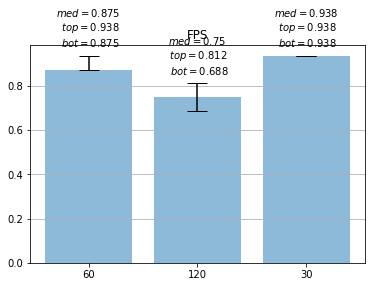

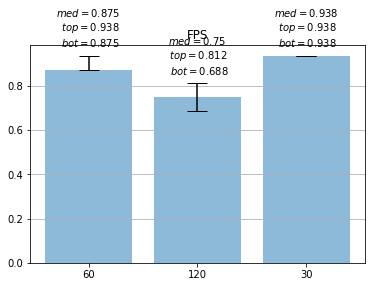

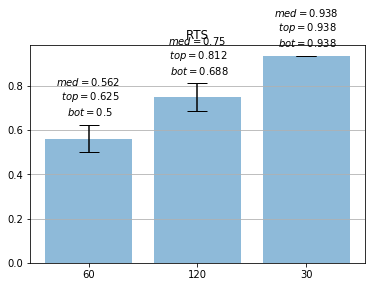

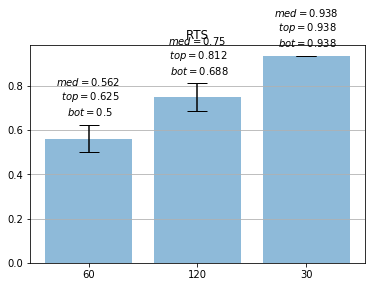

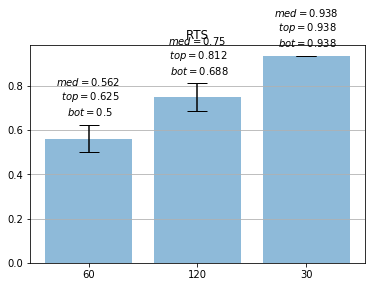

In [92]:

u_rrx = u_rr[1:]

ci_bot_in = 'ci75bot'
ci_top_in = 'ci75top'
lbls = u_rrx
for jj in u_sc:
    for ii in range(0,3):
        fig, ax = plt.subplots()
        diff = full_ci[full_ci['sc']==jj]
        
        bar_plt = ax.bar(x = np.arange(len(u_rrx)), 
               height = diff['median'], 
               yerr=[diff['median']-diff[ci_bot_in],diff[ci_top_in]-diff['median']], 
               align='center', alpha=0.5, 
               ecolor='black', capsize=10)
        ax.set_xticks(np.arange(0,3))
        ax.set_xticklabels(lbls)
        ax.set_title(jj)
        ax.yaxis.grid(True)
        # Add numbers in plot
        citop = diff[ci_top_in].tolist() 
        cibot = diff[ci_bot_in].tolist() 
        meanerr = diff['median'].tolist() 
        
        for i, rectangle in enumerate(bar_plt):
            height = rectangle.get_height()
            plt.text(rectangle.get_x() + rectangle.get_width()/2, height+citop[i]-meanerr[i]+ 0.03,
             '$med=$%s \n $top=$%s \n $bot=$%s' % (str(round(meanerr[i],3)),
                                                        str(round(citop[i],3)),
                                                        str(round(cibot[i],3))),
             ha='center', va='bottom')
        
        plt.show()